Manecillas: 4
Manecilla: 73.0, Angulo: 84.28940686250036
Manecilla: 98.0, Angulo: 355.6012946450045
Manecilla: 110.0, Angulo: 5.964487101253113
Manecilla: 121.62236636408618, Angulo: 138.88790956083307
16644746.0


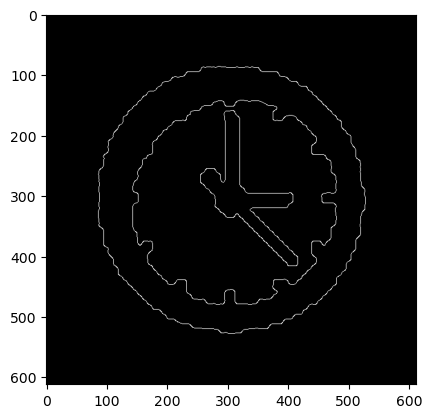

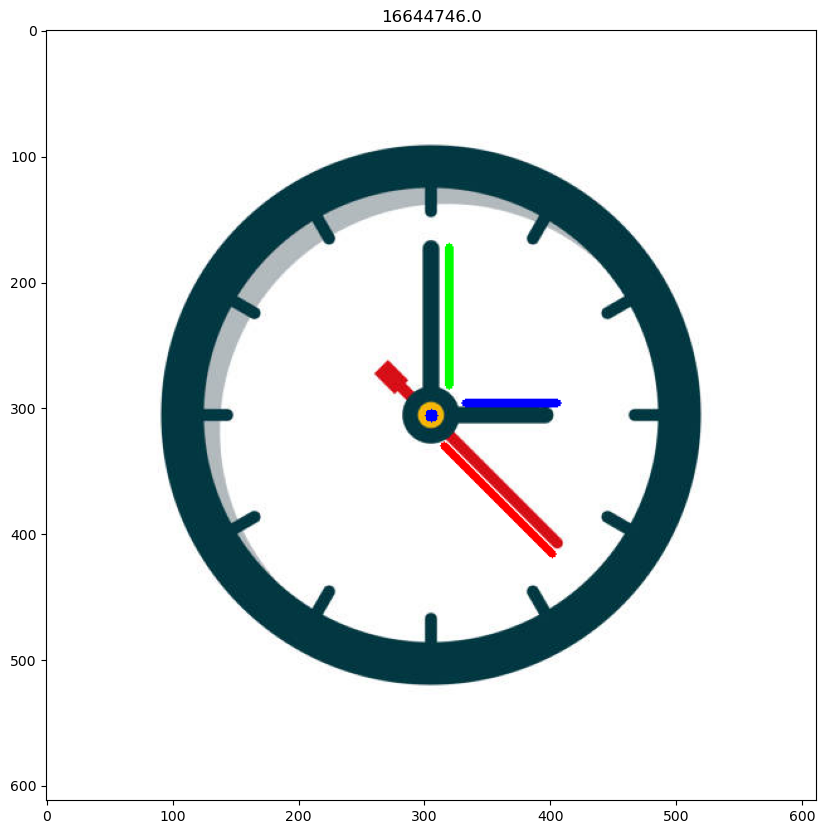

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from date_time_literal import ConvertTime
from datetime import datetime 


imagen_bgr = cv2.imread('relog2.jpg')
# imagen_bgr = cv2.imread('RELOJ.jpeg')
# imagen_bgr = cv2.imread('relog3.jpeg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.medianBlur(gris, 7)
gris = cv2.equalizeHist(gris)
plt.imshow(gris, cmap='gray')


# bordes = cv2.Canny(gris, 50, 150)
bordes = cv2.Canny(gris, 10, 150)
# bordes = cv2.Canny(gris, 20, 80)
plt.imshow(bordes, cmap='gray')

# Detección de líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    # print(f"dx: {dx}, dy: {dy}, angulo: {angulo}")
    return angulo

def convertir_horas_lit(hora):
    # Convertir la hora a un objeto DateTimeLiteral
    dt  = datetime.strptime(hora, "%H:%M:%S")
    # Crear una instancia de ConvertTime
    convert_lit = ConvertTime(dt, 'h').convert_time
    # Obtener la representación de cadena de la hora
    return str(convert_lit)


manecillas = []
if lineas is not None:
    # print(lineas)
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        # LINEAS CENTRO
        if distancia_centro < 100 and 40 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

print(f"Manecillas: {len(manecillas)}")
manecillas.sort(key=lambda x: x['longitud'])
for i in manecillas:
    print(f"Manecilla: {i['longitud']}, Angulo: {i['angulo']}")

if len(manecillas) >= 2:
    # CORTO LARGO
    # manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[0]
    minutero = manecillas[len(manecillas)//2]
    secundero = manecillas[-1]
    
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((secundero['angulo'] / 6) % 60)

    # Convertir la hora a un objeto DateTimeLiteral
    hora_literal = convertir_horas_lit(f"{hora}:{minutos}:{segundos}")

    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    imagen_resultado = imagen_rgb.copy()
    cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,(horario['puntos'][0], horario['puntos'][1]),(horario['puntos'][2], horario['puntos'][3]), (0, 0, 255), 5)  # horario azul
    cv2.line(imagen_resultado,(minutero['puntos'][0], minutero['puntos'][1]),(minutero['puntos'][2], minutero['puntos'][3]),(0, 255, 0), 5)  # minutero verde
    cv2.line(imagen_resultado,(secundero['puntos'][0], secundero['puntos'][1]),(secundero['puntos'][2], secundero['puntos'][3]),(255, 0, 0), 5)  # minutero verde

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    # plt.title(f'Hora: {hora}:{minutos:02d}:{segundos:02d}')
    plt.title(hora_literal)
    print(hora_literal)
    plt.show()

